In [30]:
import numpy as np
import matplotlib.pyplot as plt

from source.utilities import *
from source.config import *
from constants import *
from time import time
import os
testdir = f"{local_dir}/tests"
os.makedirs(testdir, exist_ok=True)

In [33]:
import math
import json
def store_state(
    config: QSHEConfig, output_dir: str | Path, vars: list, block_size: int
):
    n = config.samples
    k = config.steps
    qstep = (config.q_max - config.q_min) / config.q_num
    pstep = (config.p_max - config.p_min) / config.p_num
    fix = config.fixed
    met = config.metric
    state = {
        "q": {
            "Min": config.q_min,
            "Max": config.q_max,
            "Num": config.q_num,
            "Step": qstep,
        },
        "p": {
            "Min": config.p_min,
            "Max": config.p_max,
            "Num": config.p_num,
            "Step": pstep,
        },
        "vars": vars,
        "config": {
            "Samples": n,
            "Steps": k,
            "Fixed": bool(fix),
            "Metric": met,
            "Block size": block_size,
        },
    }
    state_filename = f"{output_dir}/trial_state.json"
    with open(state_filename, "w") as f:
        json.dump(state, f, indent=2)
    print(f"State config saved to {state_filename}")
cfg = load_yaml(f"{data_dir}/qp_unfixed_numerical_shreyas/QP/config/updated_config.yaml")
rg_config = build_config(cfg)
if rg_config.model != "qshe":
    raise SystemExit(f"Invalid model {rg_config.model}.")
if rg_config.metric == "all":
    met_dim = 3
else:
    met_dim = 1
q_block_size = 2
vars = ["p", "q"]
num_steps = rg_config.steps
num_samples = rg_config.samples
output_dir = f"{data_dir}/qp_unfixed_numerical_shreyas/QP/data"
print("Beginning aggregation step")
print("-" * 100)
start = time()
block_num = math.ceil(rg_config.q_num / q_block_size)
print(f"Num blocks = {block_num}")
if block_num * q_block_size > rg_config.q_num:
    final_block_size = (block_num * q_block_size) - rg_config.q_num
else:
    final_block_size = q_block_size
output_path = Path(output_dir)
for var in vars:
    agg_filename = output_path / f"{var}_data_agg.npy"
    final_data = np.empty(
        shape=(rg_config.q_num, rg_config.p_num, num_steps, met_dim),
        dtype=np.float64,
    )
    print(f"Final data shape = {final_data.shape}")
    for block in range(block_num):
        block_path = output_path / f"q{block}"
        if not (block_path / "DONE").exists():
            raise RuntimeError(f"Block {block} incomplete.")
        trial_data_file = (
            f"{output_dir}/q{block}/{var}_data_q{block}_{num_samples}_samples.npy"
        )
        trial_data = np.load(trial_data_file)
        if block == block_num - 1:
            q_block_size = final_block_size
            print(f"Final block {block} has size = {q_block_size}")
            start_index = rg_config.q_num - final_block_size
            end_index = rg_config.q_num
            final_data[start_index:end_index, :, :, :] = trial_data
        else:
            start_index = block * q_block_size
            end_index = min((block + 1) * q_block_size, rg_config.q_num)
            final_data[start_index:end_index, :, :, :] = trial_data
        if block % 5 == 0:
            print(f"Agg done for block {block}.")
    np.save(agg_filename, final_data)
    print(f"Trial data for {var} aggregated after {time() - start:.3f} seconds")
    print(f"Agg data saved to {agg_filename}")
print("-" * 100)
store_state(rg_config, output_dir, vars, q_block_size)
print("-" * 100)
print(
    f"All aggregation steps completed for {block_num} q blocks after {time() - start:.3f} seconds"
)

Beginning aggregation step
----------------------------------------------------------------------------------------------------
Num blocks = 25
Final data shape = (50, 500, 15, 3)
Agg done for block 0.
Agg done for block 5.
Agg done for block 10.
Agg done for block 15.
Agg done for block 20.
Final block 24 has size = 2
Trial data for p aggregated after 0.019 seconds
Agg data saved to C:\Users\ssark\Desktop\Uni\Year 4 Courses\Physics Final Year Project\Project Code\Data from taskfarm\qp_unfixed_numerical_shreyas\QP\data\p_data_agg.npy
Final data shape = (50, 500, 15, 3)
Agg done for block 0.
Agg done for block 5.
Agg done for block 10.
Agg done for block 15.
Agg done for block 20.
Final block 24 has size = 2
Trial data for q aggregated after 0.041 seconds
Agg data saved to C:\Users\ssark\Desktop\Uni\Year 4 Courses\Physics Final Year Project\Project Code\Data from taskfarm\qp_unfixed_numerical_shreyas\QP\data\q_data_agg.npy
----------------------------------------------------------------

In [7]:
def conversions(p, q):
    if not isinstance(p, np.ndarray) or not isinstance(p, int):
        p = np.array(p)
    g=  p + (1-p)*q
    z = np.log((1-g)/g)
    return g, z
known_points = [(0.188, 0.309), (0.561, 0.309), (0.563, 0.146), (0.114, 0.146), (0.142, 0.188),(0.211, 0.309)]
labels = ["C", "D", "D'", "A", "B", "C'"]
i = 0
for a, b in known_points:
    gc, zc = conversions(a,b)
    print(f"Point {labels[i]:2} : p = {a}, q = {b}, g = {round(float(gc), 3)}, z = {round(float(zc), 3):6}")
    i += 1

Point C  : p = 0.188, q = 0.309, g = 0.439, z =  0.246
Point D  : p = 0.561, q = 0.309, g = 0.697, z = -0.831
Point D' : p = 0.563, q = 0.146, g = 0.627, z = -0.519
Point A  : p = 0.114, q = 0.146, g = 0.243, z =  1.134
Point B  : p = 0.142, q = 0.188, g = 0.303, z =  0.832
Point C' : p = 0.211, q = 0.309, g = 0.455, z =  0.181


In [ ]:
gtest, ztest = conversions(np.array([0.1,0.102, 0.104, 0.106]), 0.0)
# print((np.max(ztest) - np.min(ztest)) / ztest.size)
# print(conversions([0.002, 0.012], 0.0))

# we know g = p + (1-p)*q, and z = ln((1-g)/g). If we know p, we should be able to find what q gives us z = 0, because z = 0 means g = 1/2.
# p = 0.9
# qneeded = (0.5 - p)/ (1-p)
# print(qneeded)
q = 0.0
p = 0.5
dp = 0.002
g = p + (1-p)*q
dz = dp * (q - 1)/(g*(1-g))
print(dz)

-0.008


In [14]:
def initialise_flat_2d(N):
    """
    Draw N samples uniformly from the full (t, f) simplex.
    Uses angular parametrisation: t=sin(b)cos(psi), f=sin(b)sin(psi), r=cos(b)
    with b, psi uniform in [0, pi/2].
    This is the 2D analogue of the flat Q_0(z) used by Cain & Roemer (2005).
    """
    beta = np.random.uniform(0, np.pi/2, N)
    psi  = np.random.uniform(0, np.pi/2, N)
    t = np.sin(beta) * np.cos(psi)
    f = np.sin(beta) * np.sin(psi)
    r = np.cos(beta)
    return t, f, r

## Test

In [ ]:
def rg(n, k, p_init, q_init, seed, zc):
    start = time()
    q_init = q_init
    p_init = p_init
    datadir = f"{testdir}/q{q_init}_p{p_init:.3f}/{n}"
    os.makedirs(datadir, exist_ok=True)
    rng = build_rng(seed)
    phis = generate_random_phases(n, rng, 16)
    indices = rng.integers(0, n, (n, 5))

    starting_t = np.full(n, np.sqrt(p_init))
    starting_f = np.full(n, np.sqrt((1 - p_init) * q_init))
    # starting_t, starting_f, starting_r = initialise_flat_2d(n)
    ts = np.take(starting_t, indices)
    fs = np.take(starting_f, indices)
    zmeans = np.empty(k, np.float64)
    outs = [2, 9, 10, 17]
    ins = [1.0, 0.0, 0.0, 0.0]
    nbatches = 10
    batch = n // nbatches
    vars = ["t", "r", "tau", "f", "p", "q", "g", "z"]
    vardict = np.empty(shape=(len(vars), k, n), dtype=np.float64)
    for i in range(1, k+1):
        outdict = qshe_numerical_solver(ts, fs, phis, n, outs, ins, batch)
        tp = outdict[2].ravel()
        rp = outdict[9].ravel()
        taup = outdict[10].ravel()
        # fp = outdict[17].ravel()
        pp = tp**2
        fp = np.sqrt((1 - pp)*q_init)
        qp = fp**2 / (1 - pp)
        g = tp**2 + fp**2
        g = np.clip(g, 1e-12, 1.0-1e-12)
        z = np.log((1 - g)/g)
        vardict[0, i-1, :] = tp
        vardict[1, i-1, :] = rp
        vardict[2, i-1, :] = taup
        vardict[3, i-1, :] = fp
        vardict[4, i-1, :] = pp
        vardict[5, i-1, :] = qp
        vardict[6, i-1, :] = g
        vardict[7, i-1, :] = z
        ts = np.take(tp, indices)
        fs = np.take(fp, indices)
        zmeans[i-1] = np.mean(z) - zc
        # print(f"Step {i} done after {time() - start:.3f} seconds.")
    return vardict, zmeans

In [ ]:
samps = 100000
steps = 12
s = 1234
pnum = 20
psep = 0.1
crit_points = {"C": (0.188, 0.309, 0.439, 0.246), "D": (0.561, 0.309, 0.697, -0.831), "D'": (0.563, 0.146, 0.627, -0.519)}
datas = {"C":{}, "D": {}, "D'": {}}
for label, cp in crit_points.items():
    pc, qc, _, zc = cp
    pvals = np.linspace(pc-psep, pc+psep, pnum+1)
    values = []
    means = []
    for i, pval in np.ndenumerate(pvals):
        data, zm = rg(100000, 12, pval, qc, 1234, zc)
        values.append(data)
        means.append(zm)
    datas[label].update({"data": values, "zmeans": means})
    print(f"{label} done.")

In [ ]:
vars = ["t", "r", "tau", "f", "p", "q", "g", "z"]
for label in datas.keys():
    labeldir = f"{testdir}"
    for j in range(len(vars)):
        fig, ax = plt.subplots(figsize=(8, 6))

        ax.set_title(f"Density histogram of $\\text{{{vars[j]}}}$")
        ax.set_xlabel(f"$\\text{{{vars[j]}}}$")
        ax.set_ylabel(f"P($\\text{{{vars[j]}}}$)")
        for i in range(steps):
            if vars[j] != "z":
                ax.set_ylim((0.0, 5.0))
                h, e = np.histogram(datas["C"]["data"][j, i, :], bins=samps//100, range=(0, 1), density = True)
            else:
                ax.set_ylim((0.0, 0.4))
                h, e = np.histogram(datas["C"]["data"][j, i, :], bins=samps//100, range=(-25, 25), density = True)
            c = 0.5 * (e[1:] + e[:-1])
            ax.plot(c, h, label=f"Step {i+1}")
        ax.legend(loc="upper right", bbox_to_anchor=(1.2, 1.0))
        print(f"Finished hist plotting for {vars[j]}")
        fig.savefig(f"{datadir}/{vars[j]}_{n}samples_hist.png", dpi=150, bbox_inches="tight")
        plt.close(fig)

Finished hist plotting for t
Finished hist plotting for r
Finished hist plotting for tau
Finished hist plotting for f
Finished hist plotting for p
Finished hist plotting for q
Finished hist plotting for g
Finished hist plotting for z


## Claude

In [ ]:
from scipy.stats import linregress

def run_path2(seed, p_values, q_c, z_c, N=500_000, n_steps=8):
    """
    Path 2: probe QSHE scaling with q fixed at q_c and z_c from Kobayashi.

    Parameters
    ----------
    seed : int
        Seed for initialising np.random.Generator
    p_values : array
        Range of initial p values around the known p_c.
        Example: np.linspace(0.45, 0.65, 40) for Kobayashi point D.
    q_c : float
        Fixed spin-mixing parameter. Use Kobayashi values:
        q_c = 0.309 for point D (p_c = 0.561)
        q_c = 0.146 for point D' (p_c = 0.563)
    z_c : float
        Critical z value. From Kobayashi:
        z_c = -0.831 for point D
        z_c = -0.519 for point D'
    N : int
        Samples per p value.
    n_steps : int
        Number of RG steps.

    Returns
    -------
    mean_z : array of shape (len(p_values), n_steps)
        Mean of (z - z_c) after each RG step, for each starting p.
    slopes : array of shape (n_steps,)
        d<z>/dp|_{p_c} at each step, for extracting nu.
    """
    mean_z = np.zeros((len(p_values), n_steps))
    rng = build_rng(seed)
    indices = rng.integers(0, N, (N, 5))
    phis = generate_random_phases(N, rng, 16)
    for i, p_init in np.ndenumerate(p_values):
        # Initialise delta-function ensemble at (p_init, q_c)
        t = np.full(N, np.sqrt(p_init))
        f = np.full(N, np.sqrt((1.0 - p_init) * q_c))
        # r is determined: r^2 = (1 - p_init)(1 - q_c), no need to store
        ts = np.take(t, indices)
        fs = np.take(f, indices)
        for k in range(n_steps):
            outdict = qshe_numerical_solver(ts, fs, phis, N, [2, 17], [1.0, 0.0, 0.0, 0.0], N//5)
            tp = outdict[2].ravel()
            # fp = outdict[17].ravel()
            pp = tp**2
            fp = np.sqrt((1 - pp)*q_c)
            # After RG step: repin q to q_c using propagated t only
            # This is the "fixed q" approximation
            # f = np.sqrt(np.clip(fp, 0, None))

            # Compute z and shift by z_c
            g = np.clip(tp**2 + fp**2, 1e-12, 1 - 1e-12)
            z = np.log((1.0 - g) / g)
            mean_z[i, k] = np.mean(z) - z_c
            ts = np.take(tp, indices)
            fs = np.take(fp, indices)
    print(f"Data gen for {q_c} done.")
    # Compute slope S_k = d<z>/dp at p_c for each step k
    # This uses finite differences across the p_values array
    slopes = np.zeros(n_steps)
    for k in range(n_steps):
        slope, intercept, r, _, _ = linregress(p_values, mean_z[:, k])
        slopes[k] = slope

    return mean_z, slopes

def extract_nu(slopes, n_steps, step_range=None):
    """
    Extract nu from the scaling S_k ~ 2^(k/nu).
    Uses ln(S_k) = k * ln(2) / nu, fitted by linear regression.

    Parameters
    ----------
    step_range : tuple (start, end) or None
        Which steps to include in the fit. Exclude early steps
        (not yet in scaling regime) and very late steps (saturation).
        Example: (3, 8) uses steps 3 through 7.
    """
    if step_range is None:
        step_range = (2, n_steps)

    k_vals = np.arange(n_steps)[step_range[0]:step_range[1]]
    log_slopes = np.log(np.abs(slopes[step_range[0]:step_range[1]]))

    slope_fit, intercept, r, _, stderr = linregress(k_vals, log_slopes)

    nu = np.log(2) / slope_fit
    # Error propagation: delta_nu = nu^2 * stderr / ln(2)
    nu_err = (nu**2) * stderr / np.log(2)

    print(f"Fitted ln(S_k) = {slope_fit:.4f} * k + {intercept:.4f}")
    print(f"R^2 = {r**2:.4f}")
    print(f"nu = {nu:.3f} +/- {nu_err:.3f}")

    return nu, nu_err

def plot_results(p_values, mean_z, slopes, n_steps, p_c, qc, label, savefilename = None, fixed = "fixed"):

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Plot 1: mean(z - z_c) vs p for each RG step
    # All curves should cross near p = p_c, mean = 0
    ax = axes[0]
    for k in range(n_steps):
        ax.plot(p_values, mean_z[:, k], label=f'Step {k+1}')
    ax.axhline(0, color='k', linestyle='--', linewidth=0.8)
    ax.axvline(p_c, color='k', linestyle=':', linewidth=0.8, label=f'$p_c$={p_c}')
    ax.set_xlabel(r'$p_{init}$')
    ax.set_ylabel(r'$\langle z \rangle_k - z_c$')
    ax.set_title(r'Mean shifted z vs p (should cross at $p_c$, 0)')
    ax.legend(fontsize=7)

    # Plot 2: slope S_k vs k on log scale
    ax = axes[1]
    k_arr = np.arange(1, n_steps + 1)
    ax.semilogy(k_arr, np.abs(slopes), 'o-')
    ax.set_xlabel(r'RG step $k$')
    ax.set_ylabel(r'$|S_k| = |d\langle z\rangle/dp|_{p_c}|$')
    ax.set_title(r'Slope scaling: $S_k \propto 2^{k/\nu}$')

    # Plot 3: ln(S_k) vs k — should be linear with slope ln(2)/nu
    ax = axes[2]
    ax.plot(k_arr, np.log(np.abs(slopes)), 'o-')
    ax.set_xlabel(r'RG step $k$')
    ax.set_ylabel(r'$\ln|S_k|$')
    ax.set_title(r'$\ln|S_k|$ vs $k$: slope = $\ln(2)/\nu$')
    plt.suptitle(f"$q_c$ = {qc:.3f}, $p_c$ = {p_c:.3f}")
    plt.tight_layout()
    if savefilename is None:
        plt.savefig(f'{local_dir}/ctest/path2_{label}_{fixed}_results.png', dpi=150)
    else:
        plt.savefig(f"{savefilename}/path2_{label}_{fixed}_results.png", dpi=150)
    print("Plot done.")
    # plt.show()

In [ ]:
from scipy.interpolate import UnivariateSpline
# ─── Core: pairwise crossing between two curves ──────────────────────────────

def pairwise_crossings(p_values, y1, y2, smooth=False, s=None):
    """
    Find p values where curve y1(p) and y2(p) intersect,
    i.e. roots of (y1 - y2).

    Returns list of (p_cross, y_cross) tuples.
    """
    diff = y1 - y2
    crossings = []

    if smooth:
        try:
            spl = UnivariateSpline(p_values, diff, s=s, k=3)
            roots = spl.roots()
            valid = roots[(roots >= p_values[0]) & (roots <= p_values[-1])]
            for pc in valid:
                yc = float(np.interp(pc, p_values, y1))
                crossings.append((float(pc), yc))
            return crossings
        except Exception:
            pass  # fall through to linear

    for j in range(len(diff) - 1):
        if np.isnan(diff[j]) or np.isnan(diff[j + 1]):
            continue
        if diff[j] * diff[j + 1] < 0:
            # Linear interpolation for p_cross
            frac    = -diff[j] / (diff[j + 1] - diff[j])
            p_cross = p_values[j] + frac * (p_values[j + 1] - p_values[j])
            y_cross = y1[j]      + frac * (y1[j + 1]      - y1[j])
            crossings.append((float(p_cross), float(y_cross)))

    return crossings


# ─── Main function ────────────────────────────────────────────────────────────

def find_pc_from_coarse_scan(
    p_values,
    mean_z,
    n_steps=None,
    steps_to_use=None,
    smooth=False,
    spline_s=None,
    n_transitions=1,
    plot=True,
    label="",
    save_path=None,
):
    """
    Extract p_c from a coarse scan by finding where all RG step curves
    mutually intersect — i.e. the common crossing point (p_c, y_c).

    The key insight: the curves need not cross at y=0. They cross at
    y_c = <z>_critical - z_c_used, which is nonzero if the z_c you
    subtracted does not match the model's true critical z. The crossing
    point is still a valid indicator of p_c regardless.

    Parameters
    ----------
    p_values      : array (P,)
    mean_z        : array (P, K)
        <z>_k - z_c_used for each (p, step k). Shape = (n_p, n_steps).
    n_steps       : int or None — inferred from mean_z if None
    steps_to_use  : list of int or None — 0-based step indices to include.
                    Default: skip step 0 (initial distribution).
    smooth        : bool — spline smoothing before crossing detection
    spline_s      : float or None — spline smoothing parameter
    n_transitions : int (1 or 2)
        1 for a single visible transition.
        2 for both M-OI and M-QSHI transitions (requires p scan to cover both).
    plot          : bool
    label         : str
    save_path     : str or None

    Returns
    -------
    pc_estimates : dict
        Keys: 'transition_1' (and 'transition_2' if n_transitions=2).
        Each value is a dict:
            'p_c'      : float — median p_c across all pairwise crossings
            'y_c'      : float — median y at crossing (= <z>_c_true - z_c_used)
            'p_c_std'  : float — std of p_c estimates (spread across pairs)
            'y_c_std'  : float — std of y_c estimates
            'per_pair' : list of (step_i, step_j, p_cross, y_cross)
    """
    if n_steps is None:
        n_steps = mean_z.shape[1]
    if steps_to_use is None:
        steps_to_use = list(range(1, n_steps))  # skip step 0

    # ── Collect all pairwise crossings ────────────────────────────────────────
    all_crossings = []  # (step_i, step_j, p_cross, y_cross)

    step_list = list(steps_to_use)
    for ii in range(len(step_list)):
        for jj in range(ii + 1, len(step_list)):
            ki, kj = step_list[ii], step_list[jj]
            pairs = pairwise_crossings(
                p_values, mean_z[:, ki], mean_z[:, kj],
                smooth=smooth, s=spline_s
            )
            for (pc, yc) in pairs:
                all_crossings.append((ki, kj, pc, yc))

    if not all_crossings:
        print("No pairwise crossings found. "
              "Try extending the p_values range or check your mean_z array.")
        return {}

    flat_p = np.array([x[2] for x in all_crossings])
    flat_y = np.array([x[3] for x in all_crossings])

    # ── Helper: summarise one cluster ─────────────────────────────────────────
    def _summarise(mask, label_str):
        p_sel  = flat_p[mask]
        y_sel  = flat_y[mask]
        pairs  = [all_crossings[i] for i in range(len(all_crossings)) if mask[i]]
        p_c    = float(np.median(p_sel))
        y_c    = float(np.median(y_sel))
        p_std  = float(np.std(p_sel))
        y_std  = float(np.std(y_sel))
        print(f"[{label_str}]")
        print(f"  p_c  = {p_c:.5f}  ±  {p_std:.5f}   ({mask.sum()} pairwise crossings)")
        print(f"  y_c  = {y_c:.5f}  ±  {y_std:.5f}   (offset from your z_c)")
        return {"p_c": p_c, "y_c": y_c, "p_c_std": p_std, "y_c_std": y_std, "per_pair": pairs}

    # ── Cluster into n_transitions groups ─────────────────────────────────────
    pc_estimates = {}

    if n_transitions == 1:
        pc_estimates["transition_1"] = _summarise(
            np.ones(len(flat_p), dtype=bool), "Transition 1"
        )

    elif n_transitions == 2:
        sorted_idx = np.argsort(flat_p)
        sorted_p   = flat_p[sorted_idx]
        gaps       = np.diff(sorted_p)
        split_idx  = int(np.argmax(gaps))
        p_split    = 0.5 * (sorted_p[split_idx] + sorted_p[split_idx + 1])

        mask1 = flat_p <= p_split
        mask2 = flat_p >  p_split

        if mask1.sum() == 0 or mask2.sum() == 0:
            print("Warning: could not split into two clusters — "
                  "only one transition detected. Returning single estimate.")
            pc_estimates["transition_1"] = _summarise(
                np.ones(len(flat_p), dtype=bool), "Transition 1 (single)"
            )
        else:
            pc_estimates["transition_1"] = _summarise(mask1, "Transition 1 — M-OI")
            pc_estimates["transition_2"] = _summarise(mask2, "Transition 2 — M-QSHI")

    else:
        raise ValueError("n_transitions must be 1 or 2.")

    # ── Diagnostic plot ───────────────────────────────────────────────────────
    if plot:
        colors_t = ['red', 'blue']
        fig, axes = plt.subplots(1, 2, figsize=(13, 4))

        # Left: curves with detected crossing marked
        ax = axes[0]
        for k in range(n_steps):
            alpha = 1.0 if k in steps_to_use else 0.3
            ax.plot(p_values, mean_z[:, k], alpha=alpha, label=f"Step {k+1}")
        ax.axhline(0, color='k', lw=0.8, ls='--', label="y=0 reference")

        for ti, (tname, tdata) in enumerate(pc_estimates.items()):
            c = colors_t[ti]
            ax.axvline(tdata['p_c'], color=c, lw=1.5, ls=':',
                       label=f"$p_c$={tdata['p_c']:.4f}")
            ax.axhline(tdata['y_c'], color=c, lw=1.0, ls='-.',
                       label=f"$y_c$={tdata['y_c']:.4f}")
            ax.axvspan(tdata['p_c'] - tdata['p_c_std'],
                       tdata['p_c'] + tdata['p_c_std'],
                       alpha=0.10, color=c)
            ax.scatter([tdata['p_c']], [tdata['y_c']], color=c, zorder=5, s=60, marker='*')

        ax.set_xlabel(r"$p_\mathrm{init}$")
        ax.set_ylabel(r"$\langle z \rangle_k - z_c^\mathrm{used}$")
        ax.set_title(f"Coarse scan — mutual crossing point  {label}")
        ax.legend(fontsize=7, ncol=2)

        # Right: spread of p_c estimates per crossing pair
        ax = axes[1]
        for ti, (tname, tdata) in enumerate(pc_estimates.items()):
            c    = colors_t[ti]
            pcs  = [x[2] for x in tdata['per_pair']]
            ycs  = [x[3] for x in tdata['per_pair']]
            ax.scatter(range(len(pcs)), pcs, color=c, s=20, zorder=3, label=f"{tname} $p_c$")
            ax.axhline(tdata['p_c'], color=c, lw=1.2, ls='--',
                       label=f"median = {tdata['p_c']:.4f}")
            ax.fill_between(
                [-0.5, len(pcs) + 0.5],
                tdata['p_c'] - tdata['p_c_std'],
                tdata['p_c'] + tdata['p_c_std'],
                alpha=0.10, color=c
            )

        ax.set_xlabel("Pair index  (step_i, step_j)")
        ax.set_ylabel(r"$p_c$ from pair")
        ax.set_title("Pairwise crossing spread — convergence check\n"
                     "(tight cluster = well-defined transition)")
        ax.legend(fontsize=8)

        plt.suptitle(f"p_c detection — {label}", fontsize=11)
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150)
            print(f"Saved: {save_path}")
        else:
            plt.show()

    return pc_estimates

In [ ]:
os.makedirs(f"{local_dir}/ctest", exist_ok=True)
samps = 100000
steps = 9
s = 1234
pnum = 10
psep = 0.2
# crit_points = {"C": (0.188, 0.309, 0.439, 0.246), "D": (0.561, 0.309, 0.697, -0.831), "D'": (0.563, 0.146, 0.627, -0.519)} # Kobayashi's
crit_points = {"A": (0.114, 0.146, 0.243, 1.658), "B": (0.142, 0.188, 0.303, 1.216), "C'": (0.211, 0.309, 0.455, 0.446), "C": (0.188, 0.309, 0.439, 0.246), "D": (0.21, 0.309, 0.697, -0.831), "D'": (0.563, 0.476, 0.627, -0.519)} # Mine
datas = {k : {} for k in crit_points.keys()}
nus = []
nuerrs = []
for label, cp in crit_points.items():
    pc, qc, _, zc = cp
    pvals = np.linspace(max(pc-psep, 0.01), min(pc+psep, 0.99), pnum+1)
    mz, slopes = run_path2(s, pvals, qc, zc, samps, steps)
    nu, err = extract_nu(slopes, steps)
    nus.append(nu)
    nuerrs.append(err)
    plot_results(pvals, mz, slopes, steps, pc, qc, label, "fixed")
    datas[label].update({"means": mz, "slopes": slopes, "ps": pvals})
    # for i, pval in np.ndenumerate(pvals):
    #     data, zm = rg(100000, 12, pval, qc, 1234, zc)
    #     values.append(data)
    #     means.append(zm)
    # datas[label].update({"data": values, "zmeans": means})
    print(f"{label} done.")

In [77]:
print(datas.keys())

dict_keys(['A', 'B', "C'", 'C', 'D', "D'"])


In [23]:
# pairwise_crossings
plt.ioff()
outs = {}
for lab in labels:
    out= find_pc_from_coarse_scan(datas[lab]["ps"], datas[lab]["means"], steps, n_transitions= 2, label=lab, save_path=f"{local_dir}/ctest/{lab}_test.png")
    outs.update({lab: out})

[Transition 1 — M-OI]
  p_c  = 0.02504  ±  0.00522   (13 pairwise crossings)
  y_c  = -0.07049  ±  0.00083   (offset from your z_c)
[Transition 2 — M-QSHI]
  p_c  = 0.20188  ±  0.03205   (27 pairwise crossings)
  y_c  = -0.07110  ±  0.00038   (offset from your z_c)
Saved: C:\Users\ssark\Desktop\Uni\Year 4 Courses\Physics Final Year Project\Project Code\Local data/ctest/C_test.png
[Transition 1 — M-OI]
  p_c  = 0.02536  ±  0.00534   (13 pairwise crossings)
  y_c  = 1.00651  ±  0.00083   (offset from your z_c)
[Transition 2 — M-QSHI]
  p_c  = 0.20094  ±  0.03228   (27 pairwise crossings)
  y_c  = 1.00591  ±  0.00038   (offset from your z_c)
Saved: C:\Users\ssark\Desktop\Uni\Year 4 Courses\Physics Final Year Project\Project Code\Local data/ctest/D_test.png
[Transition 1 — M-OI]
  p_c  = 0.41239  ±  0.02844   (2 pairwise crossings)
  y_c  = -0.00049  ±  0.00120   (offset from your z_c)
[Transition 2 — M-QSHI]
  p_c  = 0.61673  ±  0.00000   (1 pairwise crossings)
  y_c  = -0.00030  ±  0.000

In [31]:
print(outs["C"]["transition_1"])
transitions = ["transition_1", "transition_2"]

{'p_c': 0.02503564709560578, 'y_c': -0.0704882243453004, 'p_c_std': 0.005218610223054953, 'y_c_std': 0.0008295984433159714, 'per_pair': [(1, 2, 0.029765963270412275, -0.06889193748790566), (1, 3, 0.028966042609168914, -0.06927229206435233), (1, 4, 0.027389128150951396, -0.07002209971392057), (1, 5, 0.026408825174611517, -0.0704882243453004), (1, 6, 0.02503564709560578, -0.07114115730719471), (1, 7, 0.025995189072255107, -0.07068490433137586), (1, 8, 0.024124614356846076, -0.07157434460722192), (2, 3, 0.026534139707415597, -0.06939187053164247), (2, 4, 0.021993168594373672, -0.07009431652407128), (2, 5, 0.019494113792358207, -0.07048089705648074), (2, 6, 0.015034923488607476, -0.07117069231841289), (2, 7, 0.01838089461883206, -0.07065310170779253), (2, 8, 0.012172447514053492, -0.0716134907257787)]}


In [32]:
# print(outs["C"]["transition_1"]["p_c"])
thin_points = {}
for lab in labels:
    pcrit, qcrit, _, zcrit = crit_points[lab]
    pc1 = outs[lab][transitions[0]]["p_c"]
    yc1 = outs[lab][transitions[0]]["y_c"]
    pc2 = outs[lab][transitions[1]]["p_c"]
    yc2 = outs[lab][transitions[1]]["y_c"]
    zc_fixed1 = zcrit + yc1
    zc_fixed2 = zcrit + yc2
    g1 = convert_z_to_g(zc_fixed1)
    g2 = convert_z_to_g(zc_fixed2)
    thin_points.update({lab: [(pc1, qcrit, g1, zc_fixed1), (pc2, qcrit, g2, zc_fixed2)]})

In [45]:
print(thin_points["C"])
print(thin_points["A"])

[(0.02503564709560578, 0.309, np.float64(0.4562343462798911), 0.1755117756546996), (0.20187855219556783, 0.309, np.float64(0.4563857994716905), 0.1749013017687116)]
[(0.08580791965925248, 0.146, np.float64(0.23127002144155293), 1.2011538227784724), (0.14840232246955629, 0.146, np.float64(0.2313259399600805), 1.200839319052161)]


In [40]:
samps = 500000
steps = 9
s = 1234
pnum = 20
psep = 0.05
# crit_points = {"C": (0.188, 0.309, 0.439, 0.246), "D": (0.561, 0.309, 0.697, -0.831), "D'": (0.563, 0.146, 0.627, -0.519)} # Kobayashi's
# crit_points = {"A": (0.114, 0.146, 0.243, 1.658), "B": (0.142, 0.188, 0.303, 1.216), "C'": (0.211, 0.309, 0.455, 0.446), "C": (0.188, 0.309, 0.439, 0.246), "D": (0.21, 0.309, 0.697, -0.831), "D'": (0.563, 0.476, 0.627, -0.519)} # Mine
thin_datas = {k : {} for k in thin_points.keys()}
thin_nus = []
thin_nuerrs = []
for i in range(2):
    savefolder = f"{local_dir}/ctest/thin/transition{i+1}"
    os.makedirs(savefolder, exist_ok=True)
    for label, cp in thin_points.items():
        thin_pc, thin_qc, _, thin_zc = cp[i]
        pvals = np.linspace(max(thin_pc-psep, 0.01), min(thin_pc+psep, 0.99), pnum+1)
        mz, slopes = run_path2(s, pvals, thin_qc, thin_zc, samps, steps)
        nu, err = extract_nu(slopes, steps)
        thin_nus.append(nu)
        thin_nuerrs.append(err)
        plot_results(pvals, mz, slopes, steps, thin_pc, thin_qc, label, savefolder, "fixed")
        thin_datas[label].update({"means": mz, "slopes": slopes, "ps": pvals})
        # for i, pval in np.ndenumerate(pvals):
        #     data, zm = rg(100000, 12, pval, qc, 1234, zc)
        #     values.append(data)
        #     means.append(zm)
        # datas[label].update({"data": values, "zmeans": means})
        print(f"thin {label} for {transitions[i]} done.")

Data gen for 0.309 done.
Fitted ln(S_k) = -0.4617 * k + -2.1109
R^2 = 0.5947
nu = -1.501 +/- 0.554
Plot done.
thin C for transition_1 done.
Data gen for 0.309 done.
Fitted ln(S_k) = -0.4617 * k + -2.1147
R^2 = 0.5943
nu = -1.501 +/- 0.555
Plot done.
thin D for transition_1 done.
Data gen for 0.476 done.
Fitted ln(S_k) = -1.1351 * k + 1.3517
R^2 = 0.9954
nu = -0.611 +/- 0.019
Plot done.
thin D' for transition_1 done.
Data gen for 0.146 done.
Fitted ln(S_k) = -1.0172 * k + -0.3002
R^2 = 0.9499
nu = -0.681 +/- 0.070
Plot done.
thin A for transition_1 done.
Data gen for 0.188 done.
Fitted ln(S_k) = -1.2748 * k + 0.2925
R^2 = 0.6405
nu = -0.544 +/- 0.182
Plot done.
thin B for transition_1 done.
Data gen for 0.309 done.
Fitted ln(S_k) = -0.4617 * k + -2.1122
R^2 = 0.5946
nu = -1.501 +/- 0.554
Plot done.
thin C' for transition_1 done.
Data gen for 0.309 done.
Fitted ln(S_k) = -0.5592 * k + -2.0873
R^2 = 0.6827
nu = -1.239 +/- 0.378
Plot done.
thin C for transition_2 done.
Data gen for 0.309 d

C:\Users\ssark\AppData\Local\Temp\ipykernel_19076\4240770150.py:104: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(1, 3, figsize=(15, 4))


Plot done.
thin C' for transition_2 done.


In [41]:
# pairwise_crossings
plt.ioff()
thin_outs = {}
for lab in labels:
    thin_out= find_pc_from_coarse_scan(thin_datas[lab]["ps"], thin_datas[lab]["means"], steps, n_transitions= 2, label=lab, save_path=f"{local_dir}/ctest/thin/{lab}_test.png")
    thin_outs.update({lab: thin_out})

[Transition 1 — M-OI]
  p_c  = 0.21007  ±  0.00744   (19 pairwise crossings)
  y_c  = 0.00485  ±  0.00029   (offset from your z_c)
[Transition 2 — M-QSHI]
  p_c  = 0.24889  ±  0.00000   (1 pairwise crossings)
  y_c  = 0.00510  ±  0.00000   (offset from your z_c)
Saved: C:\Users\ssark\Desktop\Uni\Year 4 Courses\Physics Final Year Project\Project Code\Local data/ctest/thin/C_test.png
[Transition 1 — M-OI]
  p_c  = 0.21008  ±  0.00744   (19 pairwise crossings)
  y_c  = 0.00484  ±  0.00029   (offset from your z_c)
[Transition 2 — M-QSHI]
  p_c  = 0.24890  ±  0.00000   (1 pairwise crossings)
  y_c  = 0.00509  ±  0.00000   (offset from your z_c)
Saved: C:\Users\ssark\Desktop\Uni\Year 4 Courses\Physics Final Year Project\Project Code\Local data/ctest/thin/D_test.png
No pairwise crossings found. Try extending the p_values range or check your mean_z array.
[Transition 1 — M-OI]
  p_c  = 0.10432  ±  0.00249   (11 pairwise crossings)
  y_c  = 0.00020  ±  0.00003   (offset from your z_c)
[Transiti

In [99]:
from source.fitters import fit_z_peaks
# print(thin_datas["C"]["means"].shape)
# print(thin_datas["C"]["ps"])
ct2 = 0.2101
indexes = np.where(np.abs(thin_datas["C"]["ps"] - ct2) < 0.05)
# print(indexes)
cmeans = thin_datas["C"]["means"][indexes]
cps = thin_datas["C"]["ps"][indexes]
# print(cmeans)
# print(cps)
for i in range(steps):
    plt.scatter(cps, cmeans[:, i], label=f"RG {i+1}")
    s, r = fit_z_peaks(cps, cmeans[:, i])
    print(f"Step {i}: Slope = {s}, R2 = {r}, Nu = {(np.log(2**(i+1)))/np.log(s)}")
plt.legend(loc="upper right", bbox_to_anchor = (1.2, 1.0))
plt.savefig("test.png", dpi=150, bbox_inches="tight")

Step 0: Slope = 0.9830901979999443, R2 = 0.9893393863269455, Nu = -40.64329268812773
Step 1: Slope = 0.3238009612548432, R2 = 0.9841989898012403, Nu = -1.2293916868907435
Step 2: Slope = 0.10381253723241163, R2 = 0.994977497161658, Nu = -0.9180074292151037
Step 3: Slope = 0.032096276028344216, R2 = 0.9996174907091072, Nu = -0.8062158806681301
Step 4: Slope = 0.008143665010522865, R2 = 0.9999506973090265, Nu = -0.7204500841262952
Step 5: Slope = 0.0016533670898033245, R2 = 0.9999973050664338, Nu = -0.6493241416588148
Step 6: Slope = 0.003494549540495334, R2 = 0.9999963123909261, Nu = -0.8577718890556871
Step 7: Slope = 0.003589868061932962, R2 = 0.9999912476187058, Nu = -0.9849968405087411
Step 8: Slope = 0.003100934951667396, R2 = 0.9999988775628303, Nu = -1.0800327005625558


In [ ]:
# Save stuff
with open(f"{local_dir}/ctest/thin/meta.json", "w") as file:
    json.dump(thin_outs, file, indent=2)

with open(f"{local_dir}/ctest/points.json", "w") as file:
    json.dump(thin_points, file, indent=2)

# Stuff for report

In [50]:
def close_old_plots():
    """Close all old open figures"""
    openfigs = plt.get_fignums()
    for fignum in openfigs:
        plt.close(fignum)

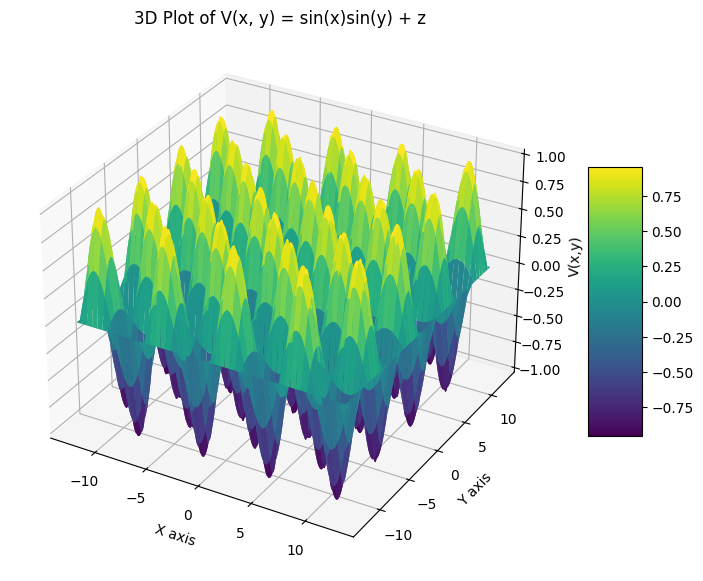

In [ ]:
close_old_plots()
num_pi = 4
x = np.linspace(-num_pi*np.pi, num_pi*np.pi, 500)
y = np.linspace(-num_pi*np.pi, num_pi*np.pi, 500)
# x = np.linspace(0, 2*np.pi, 200)
# y = np.linspace(0, 2*np.pi, 200)
xgrid, ygrid = np.meshgrid(x, y)
v = np.sin(xgrid)*np.sin(ygrid)
noise = np.random.uniform(-1e-6, 1e-6, v.shape)
v_noisy = v + noise
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Step 5: Plot the surface
surf = ax.plot_surface(xgrid, ygrid, v_noisy, cmap='viridis', edgecolor='none')
ax.set_title('3D Plot of V(x, y) = sin(x)sin(y) + z')
ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')
ax.set_zlabel('V(x,y)')

# Show the color bar
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)

# Display the plot
plt.show()

In [89]:
"""
Disorder potential: V(x, y) = sin(x)*sin(y) + u(x, y)

u(x, y) is a spatially smooth noise field generated by sampling
uniform random values on a coarse grid and bicubic-upsampling to
the fine grid — a standard approach for modelling correlated disorder
in condensed matter systems [1, 2].

The zero-contours of the gradients (dV/dx = 0, dV/dy = 0) together
identify all stationary points of V (minima, maxima, saddle points),
which play a key role in percolation-based transport models [3].

References
----------
[1] Nixon & Davies (1990). Potential fluctuations in heterostructure
    devices. Phys. Rev. B, 41(11), 7929.
[2] Fogler & Shklovskii (1994). Quantum correction to conductivity
    due to smooth disorder. Phys. Rev. B, 52(24), 17366.
[3] Isichenko (1992). Percolation, statistical topography, and
    transport in random media. Rev. Mod. Phys., 64(4), 961.
"""

import matplotlib
# matplotlib.use("Agg")           # headless; swap to "TkAgg" / remove for GUI
import matplotlib.ticker as ticker
import matplotlib.lines as mlines
from scipy.ndimage import zoom

# ── Grid ──────────────────────────────────────────────────────────────────────
N = 400
x = np.linspace(0, 4 * np.pi, N)
y = np.linspace(0, 4 * np.pi, N)
X, Y = np.meshgrid(x, y)           # each (N, N)

# ── Analytic part ─────────────────────────────────────────────────────────────
V_analytic = np.sin(X) * np.sin(Y)

# ── Smooth uniform noise u(x, y) ──────────────────────────────────────────────
# Draw U(-A, A) on a coarse grid, then bicubic-upsample for spatial correlations.
rng       = np.random.default_rng(seed=42)   # fix seed for reproducibility
N_coarse  = 20                               # coarse-grid resolution
amplitude = 0.4                              # relative noise strength

u_coarse = rng.uniform(-amplitude, amplitude, size=(N_coarse, N_coarse))
u        = zoom(u_coarse, N / N_coarse, order=3)   # bicubic → smooth field

# ── Total potential ───────────────────────────────────────────────────────────
V = V_analytic + u

# ── Gradients (second-order central differences) ──────────────────────────────
dx, dy   = x[1] - x[0], y[1] - y[0]
dVdy, dVdx = np.gradient(V, dy, dx)   # np.gradient: axis-0 = y, axis-1 = x

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))
fig.patch.set_facecolor("#000000")
ax.set_facecolor("#0d1117")

# --- 2-D colour map of V
im = ax.pcolormesh(X, Y, V, cmap="RdBu_r", shading="gouraud",
                   vmin=V.min(), vmax=V.max())

cbar = fig.colorbar(im, ax=ax, pad=0.02, fraction=0.046)
cbar.set_label(r"$V(x,y)$", color="white", fontsize=13)
cbar.ax.yaxis.set_tick_params(color="white")
plt.setp(cbar.ax.yaxis.get_ticklabels(), color="white")

# --- Critical contours
ax.contour(X, Y, dVdx, levels=[0], colors=["#00ff3c"],
           linewidths=1.6, linestyles="-")
ax.contour(X, Y, dVdy, levels=[0], colors=["#e8e83f"],
           linewidths=1.6, linestyles="--")

# Proxy artists for legend (works with all matplotlib versions)
h1 = mlines.Line2D([], [], color="#00ff3c", lw=1.6, ls="-",
                   label=r"$\partial V/\partial x = 0$")
h2 = mlines.Line2D([], [], color="#e8e83f", lw=1.6, ls="--",
                   label=r"$\partial V/\partial y = 0$")

# ── Labels & cosmetics ────────────────────────────────────────────────────────
ax.set_xlabel(r"$x$", color="white", fontsize=13)
ax.set_ylabel(r"$y$", color="white", fontsize=13)
ax.set_title(
    r"Disorder potential  $V(x,y) = \sin x \sin y + u(x,y)$" + "\n"
    r"with critical contours  $\nabla V = 0$",
    color="white", fontsize=13, pad=10,
)

# π-based tick labels
def pi_fmt(val, _):
    n = int(round(val / np.pi))
    return "0" if n == 0 else (r"$\pi$" if n == 1 else rf"${n}\pi$")

ax.xaxis.set_major_formatter(ticker.FuncFormatter(pi_fmt))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(pi_fmt))
ax.xaxis.set_major_locator(ticker.MultipleLocator(np.pi))
ax.yaxis.set_major_locator(ticker.MultipleLocator(np.pi))

for spine in ax.spines.values():
    spine.set_edgecolor("white")
ax.tick_params(colors="white")

ax.legend(handles=[h1, h2], loc="upper right", framealpha=0.3,
          labelcolor="white", fontsize=11,
          facecolor="#1c2333", edgecolor="white")

plt.tight_layout()
plt.savefig("disorder_potential.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
print("Saved → disorder_potential.png")

Saved → disorder_potential.png
